# Day 6 — Centralized CNN held-out test evaluation

This notebook loads the frozen Day 5 checkpoint and evaluates only the Day 4 `test/` shards. It does not load training or validation partitions, update model weights, or select/tune the model. All 15 original source labels remain in the report; metrics for unsupported classes are marked or handled using the documented conventions.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd()
if not (ROOT / 'results/models/centralized_cnn_v1.pt').exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.models.evaluate_cnn import evaluate_checkpoint
checkpoint = ROOT / 'results/models/centralized_cnn_v1.pt'
test_dir = ROOT / 'data/splits/mitbih_v1/test'
label_config = ROOT / 'configs/preprocessing/mitbih_v1.json'
print('Checkpoint:', checkpoint)
print('Held-out test directory:', test_dir)

Checkpoint: C:\Users\adni\Desktop\AI_Software_Engineering_Projects\blockchain-fl-arrhythmia-checkout\results\models\centralized_cnn_v1.pt
Held-out test directory: C:\Users\adni\Desktop\AI_Software_Engineering_Projects\blockchain-fl-arrhythmia-checkout\data\splits\mitbih_v1\test


## Frozen-model inference and metric generation
The reusable evaluator loads the checkpoint in evaluation mode, obtains softmax probabilities for every test segment, and writes the confusion matrix, classification report, ROC summary, predictions, and figures under `results/`.

In [2]:
evaluation = evaluate_checkpoint(checkpoint, test_dir, label_config, ROOT / 'results', batch_size=512, device='cpu')
metrics = evaluation['metrics']
print('Test size:', evaluation['test_size'], '| test record shards:', evaluation['test_record_shards'])
print('Records:', evaluation['test_record_ids'])
print('Confusion matrix label order:', evaluation['class_names'])
print(json.dumps(metrics, indent=2))

Test size: 15559 | test record shards: 7
Records: ['100', '101', '107', '113', '214', '219', '233']
Confusion matrix label order: ['/', 'A', 'E', 'F', 'J', 'L', 'N', 'Q', 'R', 'S', 'V', 'a', 'e', 'f', 'j']
{
  "accuracy": 0.7688154765730445,
  "macro_precision": 0.15104195968303255,
  "macro_recall_all_15_labels_zero_for_no_support": 0.14306930841602053,
  "macro_sensitivity_supported_classes": 0.2682549532800385,
  "weighted_sensitivity": 0.7688154765730445,
  "macro_f1": 0.13985305799635317,
  "weighted_precision": 0.707759652320602,
  "weighted_recall": 0.7688154765730445,
  "weighted_f1": 0.7208006330151878,
  "micro_precision": 0.7688154765730445,
  "micro_recall": 0.7688154765730445,
  "micro_f1": 0.7688154765730445,
  "macro_specificity_all_classes": 0.9663900450965924,
  "weighted_specificity": 0.7270351998758416,
  "macro_auroc_ovr_defined_classes": 0.6237736896009698,
  "weighted_auroc_ovr_defined_classes": 0.9003963081409875,
  "micro_auroc_ovr_flattened": 0.9624181164636079

## Per-class classification, sensitivity, specificity, and AUROC
Sensitivity is TP/(TP+FN). Specificity is one-vs-rest TN/(TN+FP). AUROC uses one-vs-rest softmax probabilities and is undefined when a test class has no positive examples. The full table is saved as CSV.

In [3]:
per_class = pd.read_csv(ROOT / 'results/metrics/baseline_classification_report.csv')
display(per_class)
print((ROOT / 'results/metrics/baseline_classification_report.txt').read_text())
display(pd.read_csv(ROOT / 'results/metrics/baseline_roc_metrics.csv'))

,label,precision,recall,sensitivity,specificity,f1_score,support,auroc_ovr,auroc_defined
0,/,0.997143,0.503850,0.503850,0.999777,0.669437,2078,0.997748,True
1,A,0.000000,0.000000,0.000000,0.999936,0.000000,50,0.759494,True
2,E,0.000000,0.000000,NaN,1.000000,0.000000,0,NaN,False
3,F,0.000000,0.000000,0.000000,1.000000,0.000000,13,0.454774,True
4,J,0.000000,0.000000,NaN,1.000000,0.000000,0,NaN,False
5,L,0.000000,0.000000,0.000000,0.975734,0.000000,2001,0.659295,True
6,N,0.823979,0.993429,0.993429,0.596419,0.900805,10197,0.933277,True
7,Q,0.000000,0.000000,0.000000,1.000000,0.000000,4,0.152909,True
8,R,0.000000,0.000000,NaN,0.992352,0.000000,0,NaN,False
9,S,0.000000,0.000000,NaN,1.000000,0.000000,0,NaN,False


              precision    recall  f1-score   support

           /     0.9971    0.5038    0.6694      2078
           A     0.0000    0.0000    0.0000        50
           E     0.0000    0.0000    0.0000         0
           F     0.0000    0.0000    0.0000        13
           J     0.0000    0.0000    0.0000         0
           L     0.0000    0.0000    0.0000      2001
           N     0.8240    0.9934    0.9008     10197
           Q     0.0000    0.0000    0.0000         4
           R     0.0000    0.0000    0.0000         0
           S     0.0000    0.0000    0.0000         0
           V     0.4445    0.6488    0.5276      1210
           a     0.0000    0.0000    0.0000         6
           e     0.0000    0.0000    0.0000         0
           f     0.0000    0.0000    0.0000         0
           j     0.0000    0.0000    0.0000         0

    accuracy                         0.7688     15559
   macro avg     0.1510    0.1431    0.1399     15559
weighted avg     0.7078   

,label,auroc,support,defined
0,macro_auroc_ovr_defined_classes_aggregate,0.623774,NaN,True
1,weighted_auroc_ovr_defined_classes_aggregate,0.900396,NaN,True
2,micro_auroc_ovr_flattened_aggregate,0.962418,NaN,True
3,/,0.997748,2078.0,True
4,A,0.759494,50.0,True
5,E,NaN,0.0,False
6,F,0.454774,13.0,True
7,J,NaN,0.0,False
8,L,0.659295,2001.0,True
9,N,0.933277,10197.0,True


## Confusion matrix
Rows are true labels and columns are predicted labels in the class order stored with the checkpoint.

,/,A,E,F,J,L,N,Q,R,S,V,a,e,f,j
true_label,,,,,,,,,,,,,,,
/,1047,0,0,0,0,296,400,0,0,0,335,0,0,0,0
A,0,0,0,0,0,0,49,0,1,0,0,0,0,0,0
E,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
F,0,0,0,0,0,0,10,0,1,0,2,0,0,0,0
J,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
L,0,0,0,0,0,0,1369,0,0,0,632,0,0,0,0
N,1,0,0,0,0,0,10130,0,57,0,9,0,0,0,0
Q,0,0,0,0,0,0,1,0,0,0,3,0,0,0,0
R,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


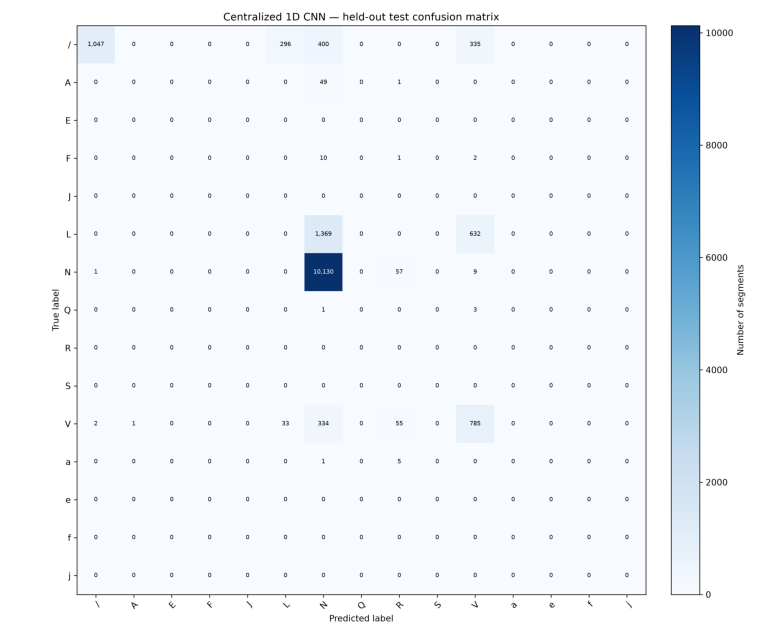

In [4]:
display(pd.read_csv(ROOT / 'results/tables/baseline_confusion_matrix.csv', index_col=0))
image = plt.imread(ROOT / 'results/figures/baseline_confusion_matrix.png')
plt.figure(figsize=(10, 8)); plt.imshow(image); plt.axis('off'); plt.show()

## One-vs-rest ROC curves
Only classes with both positive and negative test examples have an individual ROC curve. Aggregate macro AUROC is the unweighted arithmetic mean of defined class-wise AUCs; weighted AUROC weights these AUCs by test support. Micro AUROC pools all one-vs-rest decisions.

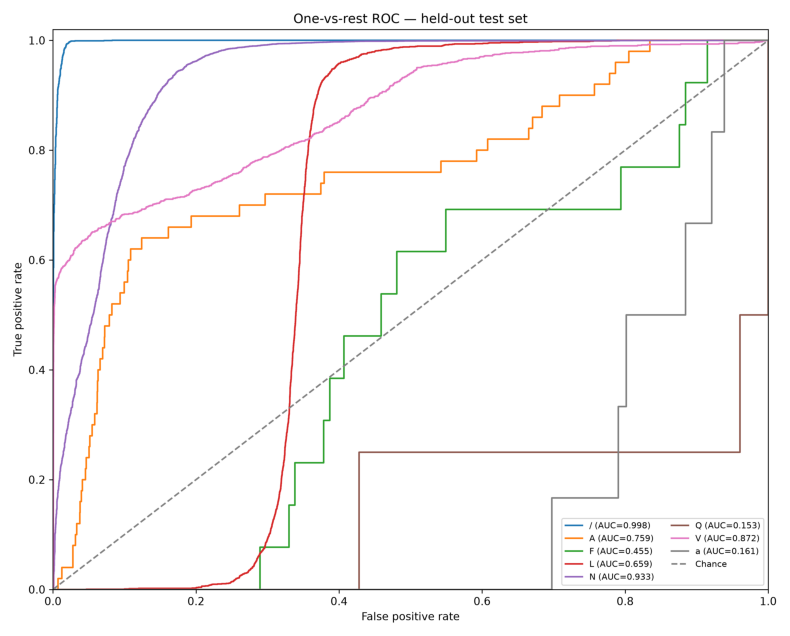

Predictions: (15559,) | probability matrix: (15559, 15)
Metrics JSON: C:\Users\adni\Desktop\AI_Software_Engineering_Projects\blockchain-fl-arrhythmia-checkout\results\metrics\baseline_metrics.json


In [5]:
roc_image = plt.imread(ROOT / 'results/figures/baseline_roc_curve.png')
plt.figure(figsize=(10, 8)); plt.imshow(roc_image); plt.axis('off'); plt.show()
pred = np.load(ROOT / 'results/metrics/baseline_test_predictions.npz', allow_pickle=False)
print('Predictions:', pred['y_pred'].shape, '| probability matrix:', pred['probabilities'].shape)
print('Metrics JSON:', ROOT / 'results/metrics/baseline_metrics.json')